# OVITO PRX Life render — fixed

Key fixes vs original:
- Type names come from LAMMPS as numeric strings ('1','4'…) → look up by `t.id` not `t.name`
- Colors + bonds must live inside pipeline modifiers, not on bare `data`
- `particles_.bonds_` double-underscore for bond property writes
- `pipeline.modifiers.append()` instead of `insert(1, ...)` on empty pipeline

In [7]:
import numpy as np
from ovito.io import import_file, export_file
from ovito.modifiers import PythonScriptModifier
from ovito.vis import Viewport, OSPRayRenderer
from ovito.data import Bonds
from ovito.pipeline import Pipeline

FILE_PATH = ('/home/xnk400/PhD/Documents/Berard2025/'
             'ParameterScanDifferentSwi6Differentp2-15-08-24/'
             'FullA/sim_p2_0.0002_noise_500_swi6_300/dump.lammpstrj')

# ── User settings ──────────────────────────────────────────────────
RENDER_FRAME  = 0
OUTPUT_IMAGE  = 'prxlife_render.png'
IMAGE_SIZE    = (1200, 900)
PARTICLE_RADIUS      = 1.0
BOND_RADIUS_FRACTION = 0.9

# Chromatin bead types — these are the beads that form the polymer
# backbone. Their type ID changes over time (A=1, U=2, M=3) but they
# are ALWAYS the first N_CHROMATIN particle IDs in the dump.
POLYMER_TYPES  = {1, 2, 3}   # all chromatin states
N_CHROMATIN    = 80          # fixed chain length — set this manually
# Bonds connect bead i → bead i+1 by sorted Particle Identifier,
# selecting only beads whose type is in POLYMER_TYPES at that frame.
# Since total chromatin count is fixed, CHAIN_LENGTHS = [N_CHROMATIN].
CHAIN_LENGTHS  = [N_CHROMATIN]

RADIUS_A = 0.5
POLYMER_RADII  = {1: RADIUS_A, 2: RADIUS_A, 3: RADIUS_A}   # chromatin
PROTEIN_RADIUS = RADIUS_A/2                           # Swi6, Epe1, etc.



# Human-readable labels
TYPE_NAMES = {
    1: 'Chromatin A',
    2: 'Chromatin U',
    3: 'Chromatin M',
    4: 'Swi6',
    5: 'Swi6M',
    6: 'Epe1',
}


In [8]:
# ── PRX Life / Okabe-Ito palette ───────────────────────────────────
def _hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))

PRX_COLORS = {
    1: _hex_to_rgb('#0072B2'),   # blue       — Chromatin A
    2: _hex_to_rgb('#F0E442'),   # yellow     — Chromatin U
    3: _hex_to_rgb('#D55E00'),   # vermillion — Chromatin M
    4: _hex_to_rgb('#CC79A7'),   # pink       — Swi6
    5: _hex_to_rgb('#009E73'),   # green      — Swi6-HDAC
    6: _hex_to_rgb('#E69F00'),   # orange     — Swi6-Epe1
    7: _hex_to_rgb('#56B4E9'),
    8: _hex_to_rgb('#000000'),
    9: _hex_to_rgb('#999999'),
   10: _hex_to_rgb('#4D4D4D'),
}
BOND_COLOR      = _hex_to_rgb("#584B4B")
CELL_LINE_COLOR = _hex_to_rgb('#AAAAAA')

In [9]:
# ── Inspect: scan frames to find ALL types that ever appear ───────
# Types evolve during the sim (beads switch A/U/M, Swi6 binds/unbinds),
# so frame 0 alone won't show the full type set.
pipeline_inspect = import_file(
    FILE_PATH,
    columns=['Particle Identifier', 'Particle Type',
             'Position.X', 'Position.Y', 'Position.Z']
)
n_frames = pipeline_inspect.source.num_frames
print(f'Total frames in trajectory: {n_frames}')

# Sample up to 20 frames evenly spaced to discover all type IDs
sample_frames = np.unique(np.linspace(0, n_frames - 1, min(20, n_frames), dtype=int))
all_type_ids = set()
for f in sample_frames:
    d = pipeline_inspect.compute(f)
    ids = {t.id for t in d.particles['Particle Type'].types}
    all_type_ids |= ids

print(f'Type IDs found across sampled frames: {sorted(all_type_ids)}')
print()

# Show counts at first and last sampled frame for reference
for check_frame in [sample_frames[0], sample_frames[-1]]:
    d = pipeline_inspect.compute(check_frame)
    ptypes = d.particles['Particle Type']
    print(f'Frame {check_frame}:')
    for t in ptypes.types:
        count = int(np.sum(np.array(ptypes) == t.id))
        label = TYPE_NAMES.get(t.id, '?')
        print(f'  type {t.id} ({label}): {count} particles')
    print()

d0 = pipeline_inspect.compute(0)
box = d0.cell.matrix
print(f'Box: {box[0,0]:.1f} x {box[1,1]:.1f} x {box[2,2]:.1f}')
print(f'Total particles per frame: {d0.particles.count} (fixed)')
pipeline = import_file(
    FILE_PATH,
    columns=['Particle Identifier', 'Particle Type',
             'Position.X', 'Position.Y', 'Position.Z']
)


Total frames in trajectory: 501
Type IDs found across sampled frames: [1, 2, 3, 4, 5]

Frame 0:
  type 1 (Chromatin A): 80 particles
  type 4 (Swi6): 300 particles

Frame 500:
  type 1 (Chromatin A): 66 particles
  type 2 (Chromatin U): 3 particles
  type 3 (Chromatin M): 11 particles
  type 4 (Swi6): 299 particles
  type 5 (Swi6M): 1 particles

Box: 50.0 x 50.0 x 50.0
Total particles per frame: 380 (fixed)


In [10]:
# ── Modifier 1: assign PRX colors — robust to evolving types ──────
# Problem: if a type first appears at frame 10, it won't be in the
# type list at frame 0. OVITO adds new ParticleType entries lazily
# as it encounters them, so we must handle types being absent.
#
# Strategy: for every type in PRX_COLORS that is NOT yet in the
# property's type list, we add it explicitly so colors are always
# pre-registered. Types present but not in PRX_COLORS get grey.


def assign_colors(frame, data):
    pt_prop = data.particles_['Particle Type_']  # mutable

    # IDs already known at this frame
    existing_ids = {t.id for t in pt_prop.types}

    # Pre-register any type from our palette not yet seen
    for type_id, color in PRX_COLORS.items():
        if type_id not in existing_ids:
            pt_prop.add_type_id(type_id,data.particles_)  # register with default props

    # Now assign colors, radii, and names to all known types
    for t in pt_prop.types_:
        t.color  = PRX_COLORS.get(t.id, (0.6, 0.6, 0.6))
        t.radius = POLYMER_RADII.get(t.id, PROTEIN_RADIUS)
        t.name  = TYPE_NAMES.get(t.id, str(t.id))

pipeline.modifiers.append(PythonScriptModifier(function=assign_colors))


In [11]:
# ── Modifier 2: backbone bonds i → i+1 ────────────────────────────
# Chromatin beads switch type (1/2/3) over time but their particle IDs
# are stable. We select all beads currently in POLYMER_TYPES each frame
# and connect them in ascending particle-ID order.
#
# CHAIN_LENGTHS guards against frames where some chromatin IDs
# temporarily read as a non-polymer type (shouldn't happen in a
# well-formed LAMMPS dump, but good to be explicit).

# def create_backbone_bonds(frame, data):
#     pids   = data.particles['Particle Identifier']
#     ptypes = data.particles['Particle Type']

#     id_to_idx = {int(pid): i for i, pid in enumerate(pids)}

#     polymer_mask = np.isin(ptypes, sorted(POLYMER_TYPES))
#     polymer_ids  = np.sort(pids[polymer_mask])
#     N_poly       = len(polymer_ids)

#     if N_poly == 0:
#         print(f'[WARN] frame {frame}: no polymer beads found in POLYMER_TYPES={POLYMER_TYPES}')
#         return

#     # Use explicit chain lengths; warn if the count doesn't match
#     chain_lengths = list(CHAIN_LENGTHS)
#     if sum(chain_lengths) != N_poly:
#         print(f'[WARN] frame {frame}: expected {sum(chain_lengths)} polymer beads, '
#               f'found {N_poly}. Some beads may have switched to a non-polymer type.\n'
#               f'       Adjust POLYMER_TYPES or N_CHROMATIN if this persists.')
#         chain_lengths = [N_poly]  # fallback: one chain of whatever we found

#     bond_pairs, pos = [], 0
#     for clen in chain_lengths:
#         chain = polymer_ids[pos:pos + clen]
#         for j in range(len(chain) - 1):
#             bond_pairs.append([id_to_idx[int(chain[j])],
#                                 id_to_idx[int(chain[j+1])]])
#         pos += clen

#     bond_arr = np.array(bond_pairs, dtype=np.int32)

#     data.particles_.create_bonds(count=len(bond_arr))
#     data.particles_.bonds_.create_property('Topology', data=bond_arr)
#     data.particles_.bonds_.create_property(
#         'Color', data=np.tile(BOND_COLOR, (len(bond_arr), 1)))
#     data.particles_.bonds_.pbc_vectors = [1,1,1]
#     bv = data.particles_.bonds_.vis
#     bv.width   = PARTICLE_RADIUS * BOND_RADIUS_FRACTION
#     bv.shading = bv.Shading.Normal


def create_backbone_bonds(frame, data):
    pids   = data.particles['Particle Identifier']
    ptypes = data.particles['Particle Type']
    pos    = np.array(data.particles['Position'])  # (N, 3) absolute coords
    cell   = data.cell.matrix[:3, :3]              # 3x3 box vectors

    id_to_idx = {int(pid): i for i, pid in enumerate(pids)}

    polymer_mask = np.isin(ptypes, sorted(POLYMER_TYPES))
    polymer_ids  = np.sort(pids[polymer_mask])
    N_poly       = len(polymer_ids)

    if N_poly == 0:
        print(f'[WARN] frame {frame}: no polymer beads found')
        return

    chain_lengths = list(CHAIN_LENGTHS)
    if sum(chain_lengths) != N_poly:
        print(f'[WARN] frame {frame}: expected {sum(chain_lengths)}, found {N_poly}')
        chain_lengths = [N_poly]

    cell_inv = np.linalg.inv(cell)
    bond_pairs, pbc_images, cursor = [], [], 0

    for clen in chain_lengths:
        chain = polymer_ids[cursor:cursor + clen]
        for j in range(len(chain) - 1):
            a = id_to_idx[int(chain[j])]
            b = id_to_idx[int(chain[j + 1])]
            bond_pairs.append([a, b])

            # Fractional displacement → nearest image
            # image[k] tells OVITO: draw bond to b + image[k]*cell[k]
            dr_frac = cell_inv @ (pos[b] - pos[a])
            image   = -np.round(dr_frac).astype(np.int32)
            pbc_images.append(image)

        cursor += clen

    bond_arr  = np.array(bond_pairs,  dtype=np.int32)
    image_arr = np.array(pbc_images,  dtype=np.int32)  # shape (N_bonds, 3)

    data.particles_.create_bonds(count=len(bond_arr))
    data.particles_.bonds_.create_property('Topology',       data=bond_arr)
    data.particles_.bonds_.create_property('Periodic Image', data=image_arr)
    data.particles_.bonds_.create_property(
        'Color', data=np.tile(BOND_COLOR, (len(bond_arr), 1)))

    bv = data.particles_.bonds_.vis
    bv.width   = RADIUS_A * BOND_RADIUS_FRACTION  # matches chromatin radius
    bv.shading = bv.Shading.Normal
pipeline.modifiers.append(PythonScriptModifier(function=create_backbone_bonds))


In [12]:
# ── Modifier 3: style the simulation cell ─────────────────────────
def style_cell(frame, data):
    if data.cell is None:
        return
    cv = data.cell_.vis
    cv.enabled         = True
    cv.line_width      = PARTICLE_RADIUS * 0.05
    cv.rendering_color = CELL_LINE_COLOR

pipeline.modifiers.append(PythonScriptModifier(function=style_cell))

In [13]:
# ── Verify pipeline runs cleanly before rendering ─────────────────

print(f'pipeline modifiers: {len(pipeline.modifiers)}')
data = pipeline.compute(RENDER_FRAME)
n_bonds = data.particles.bonds.count if data.particles.bonds else 0
print(f'Particles: {data.particles.count}, Bonds: {n_bonds}')
for t in data.particles['Particle Type'].types:
    print(f'  type {t.id} ({t.name}): color={tuple(round(float(c),3) for c in t.color)}')


pipeline modifiers: 3
Particles: 380, Bonds: 79
  type 1 (Chromatin A): color=(0.0, 0.447, 0.698)
  type 4 (Swi6): color=(0.8, 0.475, 0.655)
  type 2 (Chromatin U): color=(0.941, 0.894, 0.259)
  type 3 (Chromatin M): color=(0.835, 0.369, 0.0)
  type 5 (Swi6M): color=(0.0, 0.62, 0.451)
  type 6 (Epe1): color=(0.902, 0.624, 0.0)
  type 7 (7): color=(0.337, 0.706, 0.914)
  type 8 (8): color=(0.0, 0.0, 0.0)
  type 9 (9): color=(0.6, 0.6, 0.6)
  type 10 (10): color=(0.302, 0.302, 0.302)


In [14]:
# ── Render ────────────────────────────────────────────────────────
# Clear all modifiers and re-add them cleanly
pipeline.modifiers.clear()
pipeline.modifiers.append(PythonScriptModifier(function=assign_colors))      # your fixed version
pipeline.modifiers.append(PythonScriptModifier(function=create_backbone_bonds))
pipeline.modifiers.append(PythonScriptModifier(function=style_cell))

pipeline.add_to_scene()


In [15]:

# vp = Viewport()
# vp.type       = Viewport.Type.Perspective
# vp.camera_pos = (100, 100, 100)
# vp.camera_dir = (-1, -1, -1)
# vp.camera_up  = (0, 0, 1)


# vp.render_image(
#     filename=OUTPUT_IMAGE,
#     size=IMAGE_SIZE,
#     frame=RENDER_FRAME,
# )
# print(f'Saved → {OUTPUT_IMAGE}')

In [16]:
# vp.render_anim(
#     filename='anim.avi',
#     size=IMAGE_SIZE,
#     fps = 20
# )

In [17]:
# renderer = OSPRayRenderer()
# renderer.ambient_brightness = 0.8
# renderer.ambient_light_enabled         = True
# renderer.direct_light_enabled         = True
# renderer.principled_metalness = 0.9

# vp.render_image(
#     filename='prxlife_render_ospray.png',
#     size=IMAGE_SIZE,
#     frame=RENDER_FRAME,
#     renderer=renderer
# )
# print(f'Saved → prxlife_render_ospray.png')


In [18]:
# vp.render_anim(
#     filename='anim_ospray.avi',
#     size=IMAGE_SIZE,
#     fps = 20,
#     renderer=renderer
# # )

# Trial for good rendering of images and videos

In [ ]:
vp = Viewport()
vp.type       = Viewport.Type.Perspective
# vp.camera_pos = (100, 100, 100)
# vp.camera_dir = (-1, -1, -1)
vp.camera_pos = (-50, 25, 25)
vp.camera_dir = (-1, 1, 1)
vp.camera_up  = (0, 0, 1)

# ── OSPRay: publication still image ────────────────────────────────
renderer_image = OSPRayRenderer()
renderer_image.samples_per_pixel         = 8      # default, good balance
renderer_image.refinement_iterations     = 8      # more passes = cleaner
renderer_image.denoising_enabled         = True   # AI denoise, nearly free
renderer_image.ambient_light_enabled     = True
renderer_image.ambient_brightness        = 0.7
renderer_image.direct_light_enabled      = True
renderer_image.direct_light_intensity    = 1.2
renderer_image.direct_light_angular_diameter = np.radians(15.0)  # soft shadows
renderer_image.material_type             = 'principled'
renderer_image.principled_roughness      = 0.4   # slight sheen on spheres
renderer_image.principled_metalness      = 0.05  # mostly diffuse, tiny metallic
renderer_image.principled_specular_brightness = 0.6

vp.render_image(filename='output_small.png', size=(1600, 1200),
                frame=RENDER_FRAME, renderer=renderer_image, alpha=False)



In [ ]:
# # ── OSPRay: video frames ────────────────────────────────────────────
# renderer_video = OSPRayRenderer()
# renderer_video.samples_per_pixel         = 4      # lower: denoiser covers it
# renderer_video.refinement_iterations     = 4
# renderer_video.denoising_enabled         = True   # essential at low samples
# renderer_video.ambient_light_enabled     = True
# renderer_video.ambient_brightness        = 0.7
# renderer_video.direct_light_enabled      = True
# renderer_video.direct_light_intensity    = 1.2
# renderer_video.direct_light_angular_diameter = np.radians(10.0)
# renderer_video.material_type             = 'principled'
# renderer_video.principled_roughness      = 0.4
# renderer_video.principled_metalness      = 0.05
# renderer_video.principled_specular_brightness = 0.6

# vp.render_anim(filename='output.mp4', size=(800, 600), fps=24,
#                range=(0, 1000),
#                every_nth=10, renderer=renderer_video)

In [ ]:
from ovito.vis import Viewport
vp = Viewport()
vp.type = Viewport.Type.Perspective
vp.camera_pos = (-50, 25, 25)
vp.camera_dir = (-1, 1, 1)

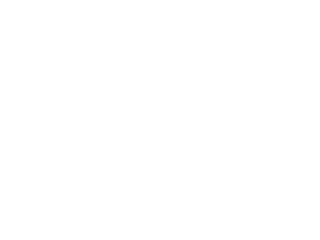

In [ ]:
vp = Viewport(type=Viewport.Type.Ortho, camera_dir=(2, 1, -1))
vp.zoom_all()
image = vp.render_image(size=(320,240))
image